<a href="https://colab.research.google.com/github/sivasooryagiri/Learn-PyTorch-for-deep-learning-in-a-day--Notes/blob/main/06_PyTorch_Transfer_lerarning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 PyTorch Transfer Learning

In [1]:
try:
  import torch
  import torchvision
  assert int(torch.__version__.split(".")[1]) >=12, "torch version should be 1.12+"
  assert int(torchvision.__version__.split(".")[1]) >=13, "torch vision version should be above 0.13"
  print(f"torch version: {torch.__version__}")
  print(f"torchvision version: {torchvision.__version__}")
except:
  print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
  !pip3 install -U torch torchvision torchaudio --extra--index--url https://download.pytorch.org/whl/cu113
  import torch
  import torchvision
  print(f"torch version: {torch.__version__}")
  print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.

Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: --extra--index--url
torch version: 2.9.0+cu126
torchvision version: 0.24.0+cu126


In [2]:
# Regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't
try:
  from torchinfo import summary
except:
  print("[INFO] Couldn't find torchinfo... installing it.")
  !pip install -q torchinfo
  from torchinfo import summary

# Import going modular form last chapter
try:
    from going_modular.going_modular import data_setup, engine
except:
  # installing form github
  !git clone https://github.com/mrdbourke/pytorch-deep-learning
  !mv pytorch-deep-learning/going_modular .
  !rm -rf pytorch-deep-learning
  from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find torchinfo... installing it.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 31.08 MiB/s, done.
Resolving deltas: 100% (2656/2656), done.
Updating files: 100% (248/248), done.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 01: Get Data

In [4]:
import os
import zipfile

from pathlib import Path
import requests

# setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# if hte image folder doesn't exist, download it and prepare it....
if image_path.is_dir():
  print(f"{image_path} directory exists.")
else:
  print(f"Did not find {image_path} directory, crating one...")
  image_path.mkdir(parents=True, exist_ok=True)

  # Download pizza, steak, sushi data
  with open(data_path/ "pizza_steak_sushi.zip", "wb") as f:
    request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("downloading pizza, steak, sushi data....")
    f.write(request.content)

  # Unziping the file
  with zipfile.ZipFile(data_path/ "pizza_steak_sushi.zip", "r") as zip_ref:
    print("Unzipping pizza, steak, sushi data....")
    zip_ref.extractall(image_path)

  os.remove(data_path/ "pizza_steak_sushi.zip")

Did not find data/pizza_steak_sushi directory, crating one...
downloading pizza, steak, sushi data....
Unzipping pizza, steak, sushi data....


In [5]:
# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

# 02: Create Datasets and DataLoaders

In [6]:
# We use torchvision.models(auto creation) for intial data transformation
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [7]:
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [8]:
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms,
                                                                               batch_size=32)

# 03: Getting a pretrained model

In [9]:
model = torchvision.models.efficientnet_b0(weights=weights).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 81.3MB/s]


In [10]:
import torchinfo
torchinfo.summary(model=model,
                  input_size=(32,3,224,224),
                  col_names=["input_size", "output_size", "num_params","trainable"],
                  col_width=20,
                  row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 16, 112

In [12]:
# Freeze all the base layers in 'features' section of the model
for params in model.features.parameters():
  params.requires_grad = False

In [15]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the len of class_names(output unit of each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape,
                    bias=True)).to(device)


In [16]:
import torchinfo
torchinfo.summary(model=model,
                  input_size=(32,3,224,224),
                  col_names=["input_size", "output_size", "num_params","trainable"],
                  col_width=20,
                  row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

## 04: Train The Model

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Timer
from timeit import default_timer as timer
start_time = timer()
# Setup training and save the results
result = engine.train(model=model,
                      train_dataloader=train_dataloader,
                      test_dataloader=test_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=50,
                      device=device)
end_time = timer()
print(f"[INFO] Total traning time: {end_time-start_time:.3f} seconds")

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.3748 | train_acc: 0.9688 | test_loss: 0.4992 | test_acc: 0.8561
Epoch: 2 | train_loss: 0.3704 | train_acc: 0.9570 | test_loss: 0.4580 | test_acc: 0.8655
Epoch: 3 | train_loss: 0.3770 | train_acc: 0.9336 | test_loss: 0.4634 | test_acc: 0.8551
Epoch: 4 | train_loss: 0.4175 | train_acc: 0.8477 | test_loss: 0.4362 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.3472 | train_acc: 0.9609 | test_loss: 0.4570 | test_acc: 0.8561
Epoch: 6 | train_loss: 0.3965 | train_acc: 0.8359 | test_loss: 0.4451 | test_acc: 0.8561
Epoch: 7 | train_loss: 0.3673 | train_acc: 0.9453 | test_loss: 0.4290 | test_acc: 0.8456
Epoch: 8 | train_loss: 0.3930 | train_acc: 0.8398 | test_loss: 0.4249 | test_acc: 0.8665
Epoch: 9 | train_loss: 0.4777 | train_acc: 0.8242 | test_loss: 0.4231 | test_acc: 0.8456
Epoch: 10 | train_loss: 0.3823 | train_acc: 0.8398 | test_loss: 0.3694 | test_acc: 0.9062
Epoch: 11 | train_loss: 0.3140 | train_acc: 0.9609 | test_loss: 0.3966 | test_acc: 0.8456
Epoch: 12 | train_l

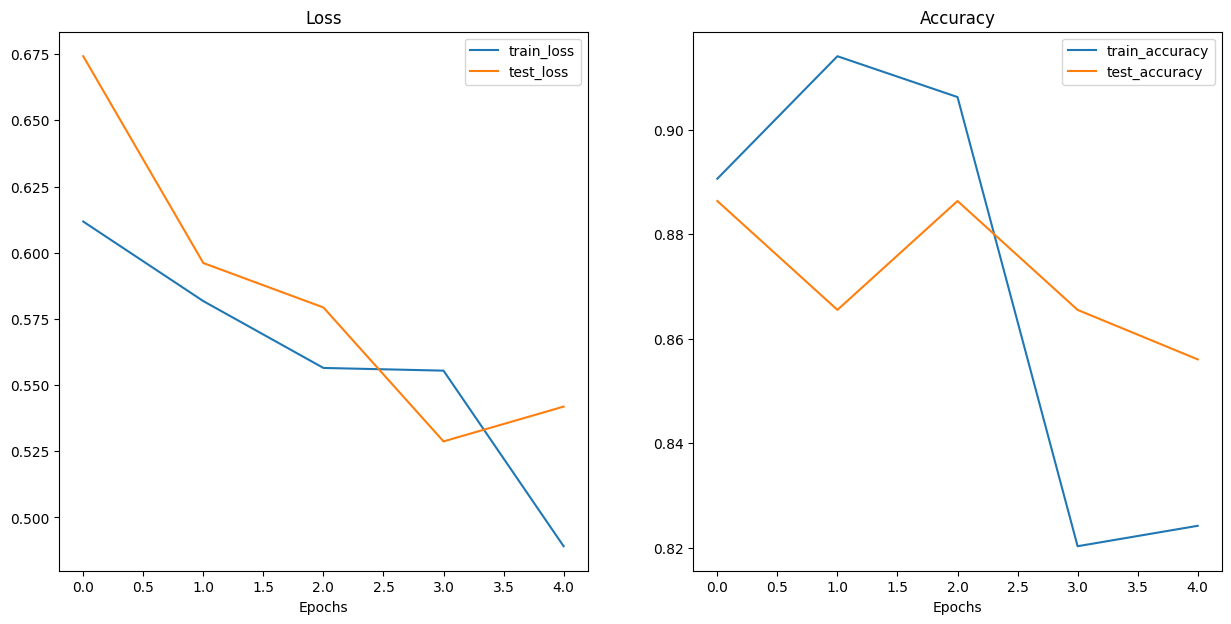

In [23]:
# Get the plot_loss_curves() function from helper_functions.py, download the file if we don't have it
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(result)